In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, utils
from tensorflow.keras.applications.resnet import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(tf.keras.__version__)

3.13.2


In [4]:
data_dir = "/content/drive/MyDrive/Bone Break Classification"

train_data = image_dataset_from_directory(
    data_dir,
    validation_split=0.1,
    subset="training",
    seed=40,
    image_size=(256, 256),
    batch_size=64
)

val_data = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(256, 256),
    batch_size=64
)

class_names = train_data.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

Found 1129 files belonging to 10 classes.
Using 1017 files for training.
Found 1129 files belonging to 10 classes.
Using 225 files for validation.
Classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [5]:
def preprocess_for_model(img):
    img = tf.cast(img, tf.float32)
    return preprocess_input(img)

train_ds = train_data.map(lambda x, y: (preprocess_for_model(x), y))
val_ds   = val_data.map(lambda x, y: (preprocess_for_model(x), y))

In [6]:
def dataset_to_numpy(dataset):
    x, y = [], []
    for img, label in dataset:
        x.append(img.numpy())
        y.append(label.numpy())
    return np.concatenate(x), np.concatenate(y)

x_train, y_train = dataset_to_numpy(train_ds)
x_val, y_val = dataset_to_numpy(val_ds)

y_train = utils.to_categorical(y_train, NUM_CLASSES)
y_val   = utils.to_categorical(y_val, NUM_CLASSES)

In [7]:
input_layer = layers.Input(shape=(256, 256, 3))

# 2. Load Base Model
base_model = ResNet50(weights="imagenet", include_top=False, input_tensor=input_layer)

# 3. Unfreeze the last 20 layers
# First, set the whole model to trainable
base_model.trainable = True

# Then, freeze everything EXCEPT the last 20 layers
# We calculate the cutoff point based on the total number of layers
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Optional but Recommended: Keep BatchNormalization layers frozen
# even in the "unfrozen" section to preserve ImageNet statistics
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# 4. Build the Head (Your custom architecture)
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(520, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# 5. Final Model construction
model = models.Model(inputs=input_layer, outputs=output)

# Verify layer status
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,251,106 (92.51 MB)

 Trainable params: 9,582,434 (36.55 MB)

 Non-trainable params: 14,668,672 (55.96 MB)

In [ ]:
"""input_layer = layers.Input(shape=(256,256,3))

base_model = ResNet50(weights="imagenet", include_top=False, input_tensor=input_layer)
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(520, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(input_layer, output)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,251,106 (92.51 MB)

 Trainable params: 663,394 (2.53 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
opt = optimizers.RMSprop(learning_rate=0.0001)

model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 815ms/step - accuracy: 0.1278 - loss: 2.3471 - val_accuracy: 0.2578 - val_loss: 2.1121
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.2203 - loss: 2.1388 - val_accuracy: 0.3644 - val_loss: 1.8579
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.3117 - loss: 1.9771 - val_accuracy: 0.5067 - val_loss: 1.6249
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.3884 - loss: 1.7927 - val_accuracy: 0.6133 - val_loss: 1.3599
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.4661 - loss: 1.5688 - val_accuracy: 0.6889 - val_loss: 1.1573
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.5388 - loss: 1.3644 - val_accuracy: 0.7422 - val_loss: 1.0365
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.6037 - loss: 1.1245 - val_accuracy: 0.7822 - val_loss: 0.8742
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.6962 - loss: 0.9230 - val_acc

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 852ms/step
Accuracy: 0.9244444444444444
Precision: 0.9290784072249589
Recall: 0.9244444444444444
F1: 0.9249297277244025
Balanced Accuracy: 0.9253650267423742
                       precision    recall  f1-score   support

    Avulsion fracture       0.83      1.00      0.91        20
  Comminuted fracture       0.84      0.93      0.89        29
 Fracture Dislocation       0.97      0.90      0.93        31
  Greenstick fracture       0.95      1.00      0.98        20
    Hairline Fracture       0.93      0.93      0.93        27
    Impacted fracture       1.00      0.89      0.94        18
Longitudinal fracture       0.89      0.89      0.89        18
     Oblique fracture       1.00      0.88      0.94        17
Pathological fracture       0.96      0.90      0.93        30
      Spiral Fracture       0.93      0.93      0.93        15

             accuracy                           0.92       225
            macro avg       0.93      0.93      0.93   

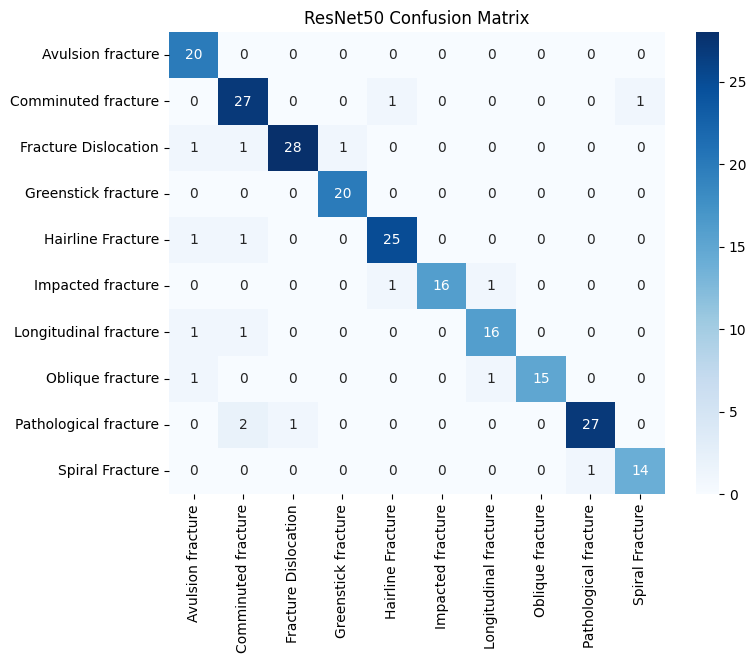

In [9]:
y_pred = np.argmax(model.predict(x_val), axis=1)
y_true = np.argmax(y_val, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))
print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [11]:
import os

folder = "/content/drive/MyDrive/Bone Break Classification/Avulsion fracture"
print(os.listdir(folder)[:5])  # show first 5 images

['Train', 'Test']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


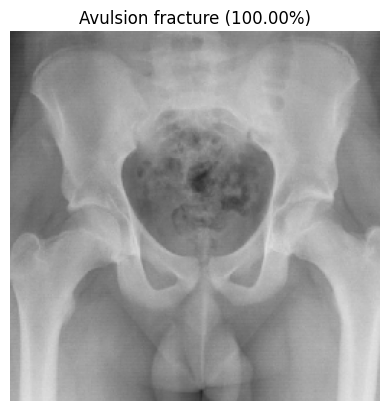

In [14]:
from tensorflow.keras.preprocessing import image

img_path = "/content/drive/MyDrive/Bone Break Classification/Avulsion fracture/Test/000002_png.rf.c3e00ebc2db78bc94e644c3f6605dad0.jpg"  # corrected path

img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)

predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Label: Fracture Dislocation
Confidence: 0.5598385


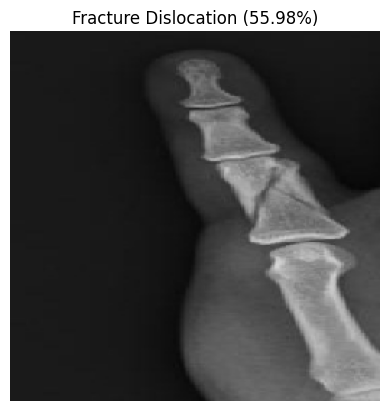

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet import preprocess_input

img_path = "/content/drive/MyDrive/Bone Break Classification/Comminuted fracture/Test/IMG-0001-00001_jumbo_jpeg.rf.4af5e7c047bac2007869a5e19663eb77.jpg"

img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)

pred_index = np.argmax(pred)
predicted_label = class_names[pred_index]
confidence = pred[0][pred_index]

# 🔥 Print results
print("Predicted Label:", predicted_label)
print("Confidence:", confidence)

# 🔥 Show image
plt.imshow(img)
plt.title(f"{predicted_label} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

In [16]:
print(class_names)

['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [17]:
top_indices = np.argsort(pred[0])[-3:][::-1]

for i in top_indices:
    print(f"{class_names[i]}: {pred[0][i]*100:.2f}%")

Fracture Dislocation: 55.98%
Avulsion fracture: 34.64%
Oblique fracture: 2.86%
